In [1]:
#env + dataset setup

import os
import torch
import numpy as np
import random

# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))


# DATASET ROOT
DATASET_ROOT = r"D:\DATASETS\YFCC100M\archive\shards"

print("Dataset path exists:", os.path.exists(DATASET_ROOT))

if os.path.exists(DATASET_ROOT):
    print("\nSample files:")
    print(os.listdir(DATASET_ROOT)[:5])


Using device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti
Total VRAM (GB): 4.29
Dataset path exists: True

Sample files:
['shard_0.msg', 'shard_1.msg', 'shard_10.msg', 'shard_100.msg', 'shard_101.msg']


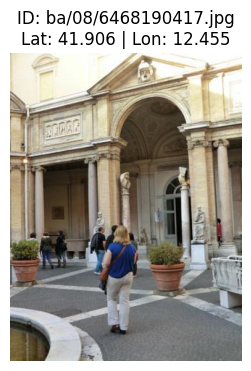

In [2]:
#visualize the data

import msgpack
import io
from PIL import Image
import matplotlib.pyplot as plt

sample_shard = os.path.join(DATASET_ROOT, "shard_0.msg")

images_to_show = 1

with open(sample_shard, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)

    for i, record in enumerate(unpacker):
        if i >= images_to_show:
            break
        
        image = Image.open(io.BytesIO(record["image"])).convert("RGB")
        
        plt.figure(figsize=(4,4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"ID: {record['id']}\nLat: {record['latitude']} | Lon: {record['longitude']}")
        plt.show()


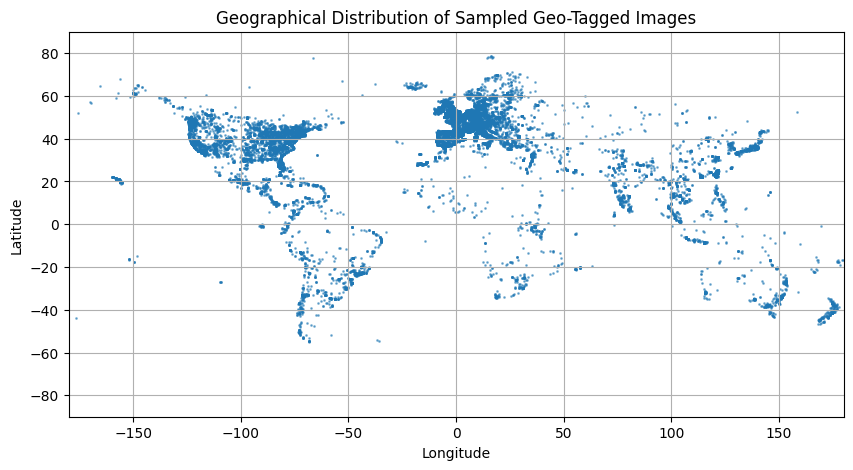

In [3]:
#geographic distribution

import matplotlib.pyplot as plt

sample_shard = os.path.join(DATASET_ROOT, "shard_0.msg")

latitudes = []
longitudes = []

with open(sample_shard, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)
    
    for i, record in enumerate(unpacker):
        latitudes.append(record["latitude"])
        longitudes.append(record["longitude"])
        if i >= 4000000:  
            break

plt.figure(figsize=(10, 5))
plt.scatter(longitudes, latitudes, s=1, alpha=0.5)

plt.title("Geographical Distribution of Sampled Geo-Tagged Images")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.grid(True)
plt.show()


In [4]:
#streaming dataset

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import msgpack
import io
import bisect

#Image transform (ResNet standard) ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class GeoMessagePackDataset(Dataset):
    def __init__(self, dataset_root, transform=None, max_records=None):
        self.dataset_root = dataset_root
        self.transform = transform
        self.shard_files = sorted([
            os.path.join(dataset_root, f)
            for f in os.listdir(dataset_root)
            if f.endswith(".msg")
        ])
        
        self.shard_sizes = []
        self.cumulative_sizes = []
        
        total = 0
        
        print("Scanning shards...")
        
        for shard_path in self.shard_files:
            count = 0
            with open(shard_path, "rb") as f:
                unpacker = msgpack.Unpacker(f, raw=False)
                for _ in unpacker:
                    count += 1
                    if max_records and total + count >= max_records:
                        count = max_records - total
                        break
            
            total += count
            self.shard_sizes.append(count)
            self.cumulative_sizes.append(total)
            
            if max_records and total >= max_records:
                break
        
        print("Total usable samples:", total)

    def __len__(self):
        return self.cumulative_sizes[-1]

    def __getitem__(self, idx):
        shard_idx = bisect.bisect_right(self.cumulative_sizes, idx)
        shard_path = self.shard_files[shard_idx]
        
        if shard_idx == 0:
            local_idx = idx
        else:
            local_idx = idx - self.cumulative_sizes[shard_idx - 1]
        
        with open(shard_path, "rb") as f:
            unpacker = msgpack.Unpacker(f, raw=False)
            for i, record in enumerate(unpacker):
                if i == local_idx:
                    image = Image.open(io.BytesIO(record["image"])).convert("RGB")
                    
                    if self.transform:
                        image = self.transform(image)
                    
                    return image, record["latitude"], record["longitude"]

        raise IndexError("Index out of range")


In [5]:
#instantiate dataset

dataset = GeoMessagePackDataset(
    dataset_root=DATASET_ROOT,
    transform=transform,
    max_records=10000  
)

print("Dataset length:", len(dataset))


Scanning shards...
Total usable samples: 10000
Dataset length: 10000


In [6]:
#samle image after tranformation
sample_image, lat, lon = dataset[0]

print("Tensor shape:", sample_image.shape)
print("Tensor dtype:", sample_image.dtype)
print("Latitude:", lat)
print("Longitude:", lon)
print("Tensor min:", sample_image.min().item())
print("Tensor max:", sample_image.max().item())


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Latitude: 41.906
Longitude: 12.455
Tensor min: -2.1007792949676514
Tensor max: 2.640000104904175


In [7]:
# ====================================================
#  RESNET50 VISUAL ENCODER
# ====================================================

import torch.nn as nn
from torchvision import models

class VisualEncoder(nn.Module):
    def __init__(self, embedding_dim=256):
        super(VisualEncoder, self).__init__()
        
        backbone = models.resnet50(pretrained=True)
        
        # Remove final classification layer
        self.feature_extractor = nn.Sequential(
            *list(backbone.children())[:-1]  
        )
        
        # Projection head
        self.embedding = nn.Linear(2048, embedding_dim)
        
    def forward(self, x):
        features = self.feature_extractor(x)      # (B, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # flatten
        embedding = self.embedding(features)
        return embedding


# Instantiate model
model = VisualEncoder(embedding_dim=256).to(device)

print("Model initialized.")


D:\ANACONDA\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\ANACONDA\envs\gpu_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model initialized.


In [8]:
#forward pass validation

model.eval()

image, lat, lon = dataset[0]

image = image.unsqueeze(0).to(device)

with torch.no_grad():
    embedding = model(image)

print("Embedding shape:", embedding.shape)
print("Embedding dtype:", embedding.dtype)


Embedding shape: torch.Size([1, 256])
Embedding dtype: torch.float32


In [9]:
from torch.utils.data import DataLoader

batch_size = 32 

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,      
    pin_memory=True         
)

print("DataLoader initialized with batch size:", batch_size)


DataLoader initialized with batch size: 32


In [10]:
model.eval()

batch = next(iter(loader))
images, latitudes, longitudes = batch

images = images.to(device, non_blocking=True)

with torch.no_grad():
    embeddings = model(images)

print("Input batch shape:", images.shape)
print("Embedding batch shape:", embeddings.shape)
print("Embedding device:", embeddings.device)


Input batch shape: torch.Size([32, 3, 224, 224])
Embedding batch shape: torch.Size([32, 256])
Embedding device: cuda:0


In [11]:
# ====================================================
# QUINTUPLET LOSS
# ====================================================

import torch.nn.functional as F

class QuintupletLoss(nn.Module):
    def __init__(self, margin1=0.2, margin2=0.2, margin3=0.2):
        super().__init__()
        self.m1 = margin1
        self.m2 = margin2
        self.m3 = margin3

    def forward(self, anchor, p1, p2, n1, n2):
        
        # Normalize embeddings for cosine distance
        anchor = F.normalize(anchor, dim=1)
        p1 = F.normalize(p1, dim=1)
        p2 = F.normalize(p2, dim=1)
        n1 = F.normalize(n1, dim=1)
        n2 = F.normalize(n2, dim=1)

        # Cosine distance = 1 - cosine similarity
        d_ap1 = 1 - F.cosine_similarity(anchor, p1)
        d_ap2 = 1 - F.cosine_similarity(anchor, p2)
        d_an1 = 1 - F.cosine_similarity(anchor, n1)
        d_an2 = 1 - F.cosine_similarity(anchor, n2)

        loss1 = F.relu(d_ap1 - d_ap2 + self.m1)
        loss2 = F.relu(d_ap2 - d_an1 + self.m2)
        loss3 = F.relu(d_an1 - d_an2 + self.m3)

        loss = loss1 + loss2 + loss3

        return loss.mean()


criterion = QuintupletLoss()
print("Quintuplet loss ready.")


Quintuplet loss ready.


In [12]:
def compute_geo_distance(latitudes, longitudes):
    """
    Compute pairwise Euclidean distance in lat/lon space.
    """
    coords = torch.stack([latitudes, longitudes], dim=1)  # (B, 2)
    
    diff = coords.unsqueeze(1) - coords.unsqueeze(0)  # (B, B, 2)
    dist = torch.sqrt((diff ** 2).sum(dim=2))  # (B, B)
    
    return dist


In [13]:
def sample_quintuplets(embeddings, latitudes, longitudes):
    
    B = embeddings.size(0)
    geo_dist = compute_geo_distance(latitudes, longitudes)
    
    anchor_list = []
    p1_list = []
    p2_list = []
    n1_list = []
    n2_list = []
    
    for i in range(B):
        distances = geo_dist[i]
        
        # sort indices by geographic distance
        sorted_indices = torch.argsort(distances)
        
        anchor = embeddings[i]
        p1 = embeddings[sorted_indices[1]]          # closest (skip self)
        p2 = embeddings[sorted_indices[3]]          # moderately close
        n1 = embeddings[sorted_indices[-3]]         # far
        n2 = embeddings[sorted_indices[-1]]         # farthest
        
        anchor_list.append(anchor)
        p1_list.append(p1)
        p2_list.append(p2)
        n1_list.append(n1)
        n2_list.append(n2)
    
    return (
        torch.stack(anchor_list),
        torch.stack(p1_list),
        torch.stack(p2_list),
        torch.stack(n1_list),
        torch.stack(n2_list),
    )


In [14]:
model.train()

batch = next(iter(loader))
images, latitudes, longitudes = batch

images = images.to(device)
latitudes = torch.tensor(latitudes, dtype=torch.float32).to(device)
longitudes = torch.tensor(longitudes, dtype=torch.float32).to(device)

# Forward pass
embeddings = model(images)

# Build quintuplets
anchor, p1, p2, n1, n2 = sample_quintuplets(
    embeddings,
    latitudes,
    longitudes
)

# Compute loss
loss = criterion(anchor, p1, p2, n1, n2)

print("Loss value:", loss.item())


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2696\1049299909.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latitudes = torch.tensor(latitudes, dtype=torch.float32).to(device)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2696\1049299909.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  longitudes = torch.tensor(longitudes, dtype=torch.float32).to(device)


Loss value: 0.5635956525802612


In [15]:
for param in model.feature_extractor.parameters():
    param.requires_grad = False

# Optimizer only for embedding layer
optimizer = torch.optim.Adam(
    model.embedding.parameters(),
    lr=1e-3
)

print("Feature extractor frozen. Embedding layer trainable.")


Feature extractor frozen. Embedding layer trainable.


In [16]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for images, latitudes, longitudes in progress_bar:
        
        images = images.to(device)
        latitudes = torch.tensor(latitudes, dtype=torch.float32).to(device)
        longitudes = torch.tensor(longitudes, dtype=torch.float32).to(device)
        
        optimizer.zero_grad()
        
        embeddings = model(images)
        
        anchor, p1, p2, n1, n2 = sample_quintuplets(
            embeddings,
            latitudes,
            longitudes
        )
        
        loss = criterion(anchor, p1, p2, n1, n2)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        progress_bar.set_postfix(loss=loss.item())
    
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2696\1276412624.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latitudes = torch.tensor(latitudes, dtype=torch.float32).to(device)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2696\1276412624.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  longitudes = torch.tensor(longitudes, dtype=torch.float32).to(device)
Epoch 1/5: 100%|██████████| 313/313 [18:10<00:00,  3.49s/it, loss=0.615]


Epoch 1 Avg Loss: 0.5942


Epoch 2/5: 100%|██████████| 313/313 [18:19<00:00,  3.51s/it, loss=0.619]


Epoch 2 Avg Loss: 0.5840


Epoch 3/5: 100%|██████████| 313/313 [18:20<00:00,  3.52s/it, loss=0.591]


Epoch 3 Avg Loss: 0.5766


Epoch 4/5: 100%|██████████| 313/313 [18:22<00:00,  3.52s/it, loss=0.609]


Epoch 4 Avg Loss: 0.5693


Epoch 5/5: 100%|██████████| 313/313 [18:33<00:00,  3.56s/it, loss=0.657]

Epoch 5 Avg Loss: 0.5603
